In [16]:
from pathlib import Path
import csv

rnx_file = Path("BUDD00DNK_R_20260110000_01D_01S_MO.rnx")
out_file = Path("GPS_D1C_doppler.csv")

# ----------------------------
# Read header and find GPS obs list
# ----------------------------
gps_obs_types = []

with open(rnx_file, "r", encoding="ascii", errors="ignore") as f:
    while True:
        line = f.readline()
        if not line:
            raise RuntimeError("Unexpected EOF before END OF HEADER")

        label = line[60:].rstrip()

        if label == "SYS / # / OBS TYPES":
            sys = line[0]
            nobs = int(line[3:6])
            obs_list = line[7:60].split()

            while len(obs_list) < nobs:
                pos = f.tell()
                nxt = f.readline()
                if not nxt:
                    raise RuntimeError("Unexpected EOF while reading SYS / # / OBS TYPES")
                if nxt[60:].rstrip() != "SYS / # / OBS TYPES":
                    f.seek(pos)
                    break
                obs_list.extend(nxt[7:60].split())

            if sys == "G":
                gps_obs_types = obs_list[:nobs]

        elif label == "END OF HEADER":
            break

if not gps_obs_types:
    raise RuntimeError("No GPS observation types found")

if "D1C" not in gps_obs_types:
    raise RuntimeError("GPS D1C not found in file")

gps_nobs = len(gps_obs_types)
d1c_index = gps_obs_types.index("D1C")

print("GPS obs types:", gps_obs_types)
print("D1C index:", d1c_index)

def parse_obs_fields(obs_text, nobs):
    vals = []
    for i in range(nobs):
        chunk = obs_text[i * 16:(i + 1) * 16]
        if not chunk:
            vals.append(None)
            continue
        val = chunk[:14].strip()
        try:
            vals.append(float(val) if val else None)
        except ValueError:
            vals.append(None)
    return vals

# ----------------------------
# Extract only GPS D1C
# ----------------------------
with open(rnx_file, "r", encoding="ascii", errors="ignore") as f, \
     open(out_file, "w", newline="", encoding="utf-8") as out:

    writer = csv.writer(out)
    writer.writerow(["time", "sv", "doppler"])

    # skip header
    while True:
        line = f.readline()
        if not line:
            raise RuntimeError("Unexpected EOF before data")
        if line[60:].rstrip() == "END OF HEADER":
            break

    epoch_count = 0
    row_count = 0

    while True:
        line = f.readline()
        if not line:
            break

        if not line.startswith(">"):
            continue

        epoch_count += 1

        year = int(line[2:6])
        month = int(line[7:9])
        day = int(line[10:12])
        hour = int(line[13:15])
        minute = int(line[16:18])
        second = float(line[19:29])
        nsat = int(line[32:35])

        epoch_str = f"{year:04d}-{month:02d}-{day:02d} {hour:02d}:{minute:02d}:{second:06.3f}"

        if epoch_count % 1000 == 0:
            print(f"Processed {epoch_count} epochs, wrote {row_count} rows")

        for _ in range(nsat):
            sat_line = f.readline()
            if not sat_line:
                break

            sv = sat_line[0:3]

            # skip non-GPS satellites
            if not sv.startswith("G"):
                continue

            obs_text = sat_line[3:].rstrip("\n")
            needed_chars = gps_nobs * 16

            # read continuation lines if needed
            while len(obs_text) < needed_chars:
                cont = f.readline()
                if not cont:
                    break
                obs_text += cont.rstrip("\n")

            vals = parse_obs_fields(obs_text, gps_nobs)
            d1c = vals[d1c_index]

            if d1c is not None:
                writer.writerow([epoch_str, sv, d1c])
                row_count += 1

print(f"Done. Wrote {out_file}")

GPS obs types: ['C1C', 'C1L', 'C1W', 'C2L', 'C2W', 'C5Q', 'D1C', 'D1L', 'D2L', 'D2W', 'D5Q', 'L1C', 'L1L', 'L2L', 'L2W', 'L5Q', 'S1C', 'S1L', 'S1W', 'S2L', 'S2W', 'S5Q']
D1C index: 6
Processed 1000 epochs, wrote 5994 rows
Processed 2000 epochs, wrote 11994 rows
Processed 3000 epochs, wrote 18058 rows
Processed 4000 epochs, wrote 24251 rows
Processed 5000 epochs, wrote 30273 rows
Processed 6000 epochs, wrote 36331 rows
Processed 7000 epochs, wrote 42331 rows
Processed 8000 epochs, wrote 48268 rows
Processed 9000 epochs, wrote 54094 rows
Processed 10000 epochs, wrote 60885 rows
Processed 11000 epochs, wrote 66971 rows
Processed 12000 epochs, wrote 73209 rows
Processed 13000 epochs, wrote 80018 rows
Processed 14000 epochs, wrote 86858 rows
Processed 15000 epochs, wrote 93006 rows
Processed 16000 epochs, wrote 99005 rows
Processed 17000 epochs, wrote 105611 rows
Processed 18000 epochs, wrote 112547 rows
Processed 19000 epochs, wrote 118969 rows
Processed 20000 epochs, wrote 124453 rows
Pro

In [19]:
import pandas as pd

df = pd.read_csv("GPS_D1C_doppler.csv")

wanted = ["G01", "G05", "G12"]
filtered = df[df["sv"].isin(wanted)]

filtered.to_csv("selected_satellites.csv", index=False)
filtered = filtered.sort_values(["sv", "time"])
filtered

,time,sv,doppler
0,2026-01-11 00:00:00.000,G01,-2593.314
6,2026-01-11 00:00:02.000,G01,-2593.983
12,2026-01-11 00:00:04.000,G01,-2595.105
18,2026-01-11 00:00:06.000,G01,-2595.567
24,2026-01-11 00:00:08.000,G01,-2596.394
...,...,...,...
261958,2026-01-11 23:59:50.000,G12,-543.043
261964,2026-01-11 23:59:52.000,G12,-543.743
261970,2026-01-11 23:59:54.000,G12,-545.780
261976,2026-01-11 23:59:56.000,G12,-546.391


In [93]:
sat_data = {
    sv: {
        "time": grp["time"].tolist(),
        "doppler": grp["doppler"].tolist()
    }
    for sv, grp in df.groupby("sv")
}

print(sat_data["G16"]["time"][1900:1903])
print(sat_data["G16"]["doppler"][1900:1903])


['2026-01-11 03:22:20.000', '2026-01-11 03:22:22.000', '2026-01-11 03:22:24.000']
[185.816, 184.013, 182.436]


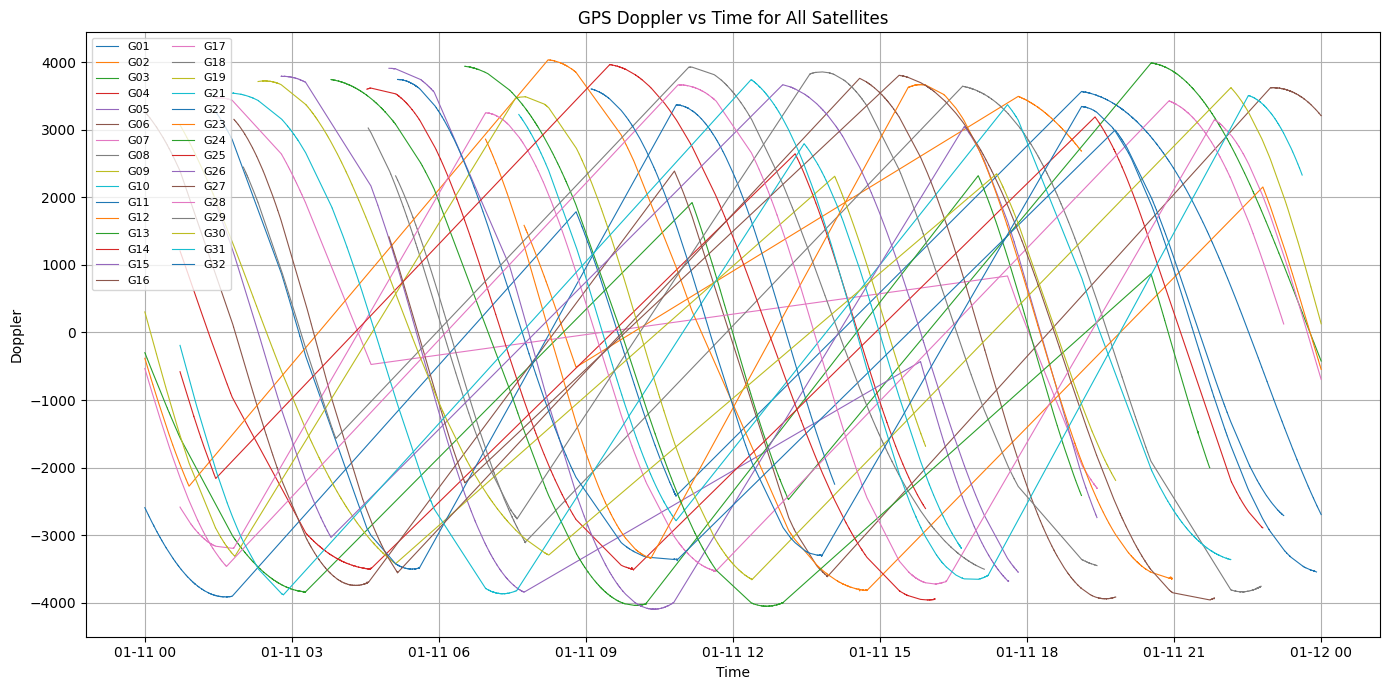

In [66]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(14, 7))
sv=["G07","G06","G04","G03","G02","G01",]
for sv, data in sat_data.items():
    t = pd.to_datetime(data["time"])
    d = data["doppler"]
    plt.plot(t, d, label=sv, linewidth=0.8)

plt.xlabel("Time")
plt.ylabel("Doppler")
plt.title("GPS Doppler vs Time for All Satellites")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

In [72]:
import pandas as pd

def visible_sats_in_window(sat_data, start_time, minutes=12.5, min_points=376):
    start = pd.Timestamp(start_time)
    end = start + pd.Timedelta(minutes=minutes)

    visible = []
    segments = {}

    for sat, data in sat_data.items():
        t = pd.to_datetime(data["time"])
        d = pd.Series(data["doppler"])

        mask = (t >= start) & (t <= end)
        t_seg = t[mask]
        d_seg = d[mask]

        if len(t_seg) >= min_points:
            visible.append(sat)
            segments[sat] = {
                "time": t_seg.tolist(),
                "doppler": d_seg.tolist()
            }

    return visible, segments

In [74]:
visible, segments = visible_sats_in_window(
    sat_data,
    start_time="2026-01-11 02:00:00",
    minutes=12.5,
    min_points=376
)

print("Visible sats:", visible)
print("Count:", len(visible))

Visible sats: ['G03', 'G06', 'G09', 'G16', 'G21']
Count: 5


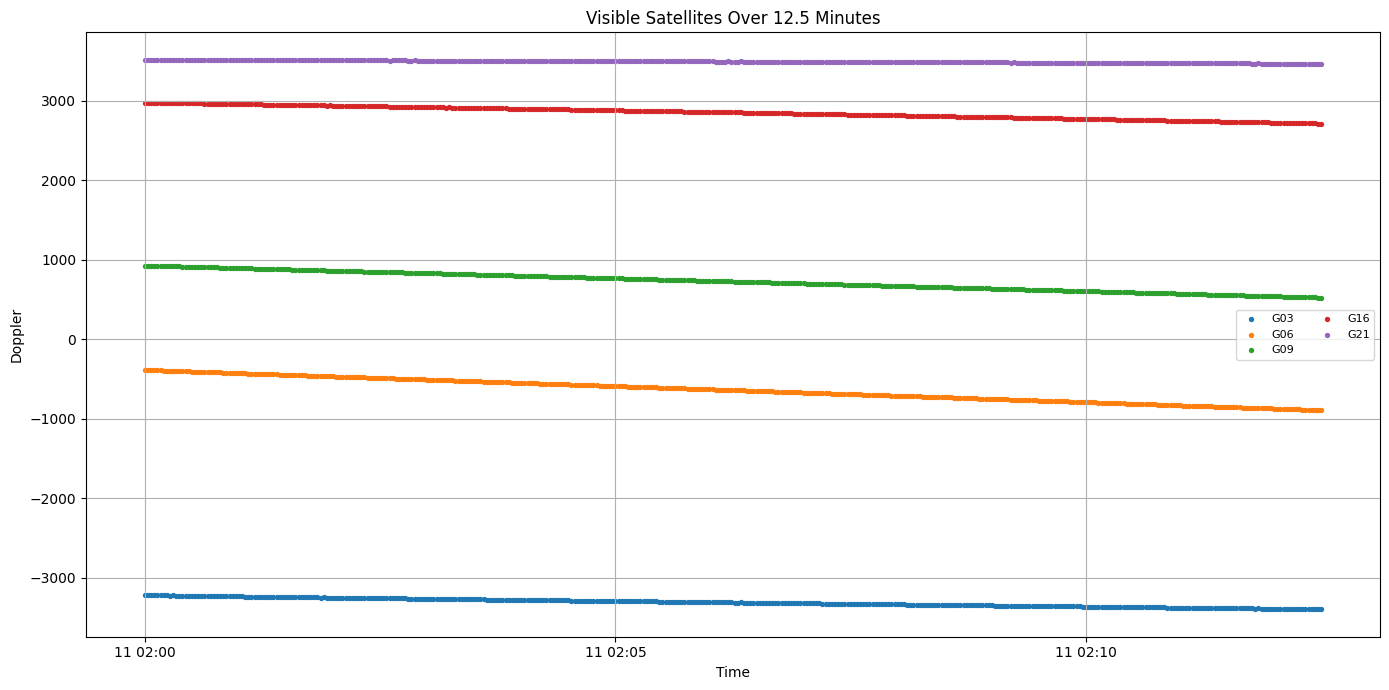

In [75]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(14, 7))

for sat in visible:
    if sat in segments:
        t = pd.to_datetime(segments[sat]["time"])
        d = segments[sat]["doppler"]
        plt.scatter(t, d, label=sat, s=8)

plt.xlabel("Time")
plt.ylabel("Doppler")
plt.title("Visible Satellites Over 12.5 Minutes")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

In [53]:
import pandas as pd

def filter_continuous_satellites_15min(sat_data, start_time, max_gap_seconds=2):
    start = pd.Timestamp(start_time)
    end = start + pd.Timedelta(minutes=15)

    selected = {}

    for sv, data in sat_data.items():
        t = pd.to_datetime(data["time"]).sort_values()
        d = pd.Series(data["doppler"], index=t).sort_index()

        mask = (t >= start) & (t < end)
        t_win = t[mask]
        d_win = d.loc[t_win]

        if len(t_win) == 0:
            continue

        covers_window = (
            t_win[0] <= start and
            t_win[-1] >= end - pd.Timedelta(seconds=1)
        )

        gaps_ok = True
        if len(t_win) > 1:
            gaps = t_win.to_series().diff().dropna()
            gaps_ok = (gaps <= pd.Timedelta(seconds=max_gap_seconds)).all()

        if covers_window and gaps_ok:
            selected[sv] = {
                "time": t_win.tolist(),
                "doppler": d_win.tolist()
            }

    return selected

selected = filter_continuous_satellites_15min(
    sat_data,
    start_time="2026-01-11 02:00:00",
    max_gap_seconds=10000
)

print(sorted(selected.keys()))

[]


In [55]:
import pandas as pd

t = pd.to_datetime(sat_data["G06"]["time"]).sort_values()

start = pd.Timestamp("2026-01-11 02:00:00")
end = start + pd.Timedelta(minutes=15)

mask = (t >= start) & (t < end)
t_win = t[mask]

print("total points:", len(t))
print("points in window:", len(t_win))

if len(t_win) > 0:
    print("first in window:", t_win[0])
    print("last in window:", t_win[-1])
    print("window start:", start)
    print("window end:", end)
    print("start diff (s):", (t_win[0] - start).total_seconds())
    print("end diff (s):", (end - t_win[-1]).total_seconds())

    if len(t_win) > 1:
        gaps = t_win.to_series().diff().dropna()
        print("max gap (s):", gaps.max().total_seconds())

total points: 8464
points in window: 450
first in window: 2026-01-11 02:00:00
last in window: 2026-01-11 02:14:58
window start: 2026-01-11 02:00:00
window end: 2026-01-11 02:15:00
start diff (s): 0.0
end diff (s): 2.0
max gap (s): 2.0


In [84]:
import pandas as pd

time = pd.to_datetime(sat_data["G16"]["time"])
doppler = sat_data["G16"]["doppler"]

start = pd.Timestamp("2026-01-11 02:00:00")
end = start + pd.Timedelta(minutes=12, seconds=30)

mask = (time >= start) & (time <= end)

time_12_5min = time[mask].tolist()
doppler_12_5min = pd.Series(doppler)[mask].tolist()

print("number of points:", len(doppler_12_5min))
print("first time:", time_12_5min[0] if time_12_5min else None)
print("last time:", time_12_5min[-1] if time_12_5min else None)

number of points: 376
first time: 2026-01-11 02:00:00
last time: 2026-01-11 02:12:30
